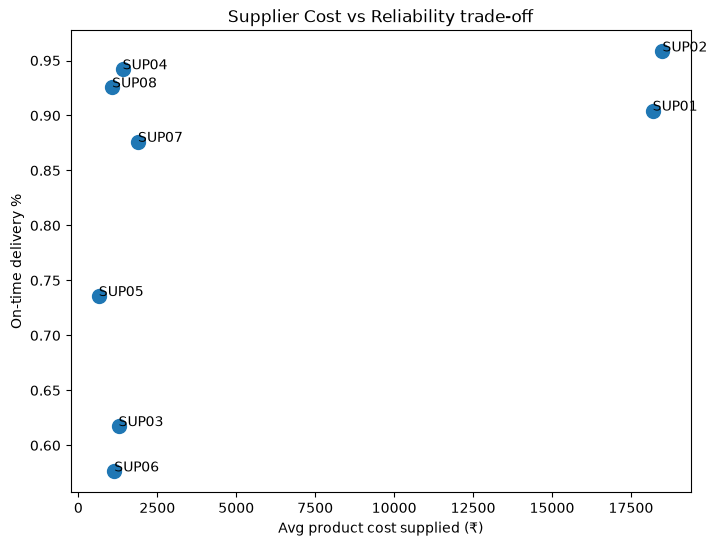

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# assumes you exported v_supplier_performance to CSV via psql \copy
sup_perf = pd.read_csv("../reports/Q6_supplier_delivery_performance.csv")
supplier = pd.read_csv("../data/raw/dim_supplier.csv")
product = pd.read_csv("../data/raw/dim_product.csv")

# proxy "cost" per supplier = avg cost_price of products they supply
avg_cost = product.merge(supplier, left_on="primary_supplier_id", right_on="supplier_id") \
                   .groupby("supplier_id")["cost_price"].mean().reset_index()
plot_df = sup_perf.merge(avg_cost, on="supplier_id")

plt.figure(figsize=(8,6))
plt.scatter(plot_df["cost_price"], plot_df["on_time_delivery_pct"], s=100)
for _, r in plot_df.iterrows():
    plt.annotate(r["supplier_id"], (r["cost_price"], r["on_time_delivery_pct"]))
plt.xlabel("Avg product cost supplied (₹)")
plt.ylabel("On-time delivery %")
plt.title("Supplier Cost vs Reliability trade-off")
plt.show()

In [8]:
print(plot_df.columns.tolist())
print(plot_df[[
    "supplier_id",
    "on_time_delivery_pct",
    "cost_price"
]].sort_values("on_time_delivery_pct", ascending=False))

['supplier_id', 'supplier_name', 'total_deliveries', 'on_time_delivery_pct', 'fill_rate', 'lead_time_variability_days', 'defect_rate', 'cost_price']
  supplier_id  on_time_delivery_pct    cost_price
7       SUP02                0.9582  18497.445000
6       SUP04                0.9420   1400.723333
5       SUP08                0.9255   1066.077500
4       SUP01                0.9044  18188.411667
3       SUP07                0.8760   1888.295000
2       SUP05                0.7357    647.123333
1       SUP03                0.6174   1271.890000
0       SUP06                0.5762   1135.742500
